# Ecommify — Implementación MongoDB Atlas optimizada U5

Este notebook usa como base directa `02_MongoDB_Atlas_Ecommify.ipynb`: conserva su carga de CSV, nombres de datasets (`dfs['category']`, `dfs['products']`, etc.), limpieza y preparación documental.

Añade lo requerido para U5 / Entregable 2 punto C: índices compuestos/parciales/texto, pipelines optimizados, evidencias con `explain`, métricas, sharding teórico, replica sets y exportables para GitHub.


## 0. Decisiones de diseño

Según el EDA del proyecto, el dataset contiene 9 tablas principales y el catálogo tiene productos con atributos variables. Por eso, en MongoDB se modelan principalmente:

- `products`: catálogo enriquecido, con categoría embebida y atributos opcionales.
- `reviews`: reseñas con score estructurado y comentarios opcionales.
- `product_catalog_view`: vista desnormalizada para frontend y analítica.
- `user_behavior`: eventos sintéticos de navegación.
- `recommendations`: recomendaciones precalculadas.

Patrones aplicados:

- **Embedding:** categoría y dimensiones dentro de productos; comentarios dentro de reseñas; eventos dentro de sesión.
- **Referencing:** `product_id`, `order_id` y `customer_id` como claves compartidas con PostgreSQL.
- **Computed Pattern:** métricas agregadas como `avg_review_score`, `total_sales` y `total_revenue`.
- **Subset Pattern:** se carga solo la información más consultada para mantener documentos compactos y respetar el límite de Atlas M0.

> Nota: MongoDB Atlas M0 no debe usarse como motor de sincronización en tiempo real para este proyecto. La sincronización propuesta es por lotes mediante ETL en Colab.

## 1. Instalación de librerías

In [1]:
!pip -q install pymongo dnspython python-dotenv tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.9 MB/s eta 0:00:00


## 2. Imports y configuración general

In [2]:
import os
import math
import json
import random
import getpass
from datetime import datetime, timezone, timedelta
from urllib.parse import quote_plus
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pymongo import MongoClient, ASCENDING, DESCENDING, TEXT
from pymongo.errors import CollectionInvalid, BulkWriteError, DuplicateKeyError
from bson import BSON

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

DB_NAME = 'ecommify_mongodb'
RESET_COLLECTIONS = True
BATCH_SIZE = 1000
RANDOM_SEED = 42
SYNTHETIC_SESSIONS = 1000

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

LOAD_TS = datetime.now(timezone.utc)
print('Timestamp de carga:', LOAD_TS.isoformat())

Timestamp de carga: 2026-06-15T16:06:49.066740+00:00


## 3. Montar Drive y cargar CSVs

Esta sección reutiliza la lógica base del notebook `01_EDA_Ecommify.ipynb`: montar Google Drive, definir `DATA_PATH` y cargar los CSV del dataset Olist.

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('No se ejecuta en Colab o Drive ya está montado:', e)

# Ajustar esta ruta a la carpeta donde están los CSV del proyecto.
DEFAULT_DATA_PATH = '/content/drive/MyDrive/Ecommify/data'
DATA_PATH = input(f'Ruta de CSV [{DEFAULT_DATA_PATH}]: ').strip() or DEFAULT_DATA_PATH

files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category': 'product_category_name_translation.csv',
}

assert os.path.isdir(DATA_PATH), f'No existe DATA_PATH: {DATA_PATH}'

missing_files = [fname for fname in files.values() if not os.path.exists(os.path.join(DATA_PATH, fname))]
assert not missing_files, f'Faltan archivos: {missing_files}'

dfs = {name: pd.read_csv(os.path.join(DATA_PATH, fname)) for name, fname in files.items()}

summary = pd.DataFrame(
    [(name, df.shape[0], df.shape[1], round(df.memory_usage(deep=True).sum() / 1024**2, 2)) for name, df in dfs.items()],
    columns=['tabla', 'filas', 'columnas', 'memoria_MB']
).sort_values('filas', ascending=False)
summary

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta de CSV [/content/drive/MyDrive/Ecommify/data]: 


,tabla,filas,columnas,memoria_MB
1,geolocation,1000163,5,129.38
3,order_items,112650,7,35.99
4,order_payments,103886,5,16.23
0,customers,99441,5,26.59
2,orders,99441,8,52.94
5,order_reviews,99224,7,39.12
6,products,32951,9,6.30
7,sellers,3095,4,0.59
8,category,71,2,0.01


## 4. Validación inicial de estructura, tipos y nulos

In [5]:
required_columns = {
    'products': ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'],
    'category': ['product_category_name', 'product_category_name_english'],
    'order_reviews': ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'],
    'order_items': ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'],
    'orders': ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp'],
    'customers': ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state'],
    'sellers': ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'],
    'order_payments': ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'],
}

for table, cols in required_columns.items():
    missing = [c for c in cols if c not in dfs[table].columns]
    assert not missing, f'{table} no tiene columnas requeridas: {missing}'

quality = []
for name, df in dfs.items():
    quality.append({
        'tabla': name,
        'filas': len(df),
        'columnas': len(df.columns),
        'duplicados_exactos': int(df.duplicated().sum()),
        'nulos_totales': int(df.isna().sum().sum())
    })
quality_df = pd.DataFrame(quality)
display(quality_df)

for name in ['products', 'order_reviews', 'order_items', 'orders']:
    print('\n', '=' * 80)
    print(name)
    display(dfs[name].isna().mean().mul(100).round(2).sort_values(ascending=False).head(12).rename('% nulos'))

,tabla,filas,columnas,duplicados_exactos,nulos_totales
0,customers,99441,5,0,0
1,geolocation,1000163,5,261831,0
2,orders,99441,8,0,4908
3,order_items,112650,7,0,0
4,order_payments,103886,5,0,0
5,order_reviews,99224,7,0,145903
6,products,32951,9,0,2448
7,sellers,3095,4,0,0
8,category,71,2,0,0



products


,% nulos
product_category_name,1.85
product_description_lenght,1.85
product_name_lenght,1.85
product_photos_qty,1.85
product_weight_g,0.01
product_height_cm,0.01
product_length_cm,0.01
product_width_cm,0.01
product_id,0.00



order_reviews


,% nulos
review_comment_title,88.34
review_comment_message,58.70
review_id,0.00
review_score,0.00
order_id,0.00
review_creation_date,0.00
review_answer_timestamp,0.00



order_items


,% nulos
order_id,0.0
order_item_id,0.0
product_id,0.0
seller_id,0.0
shipping_limit_date,0.0
price,0.0
freight_value,0.0



orders


,% nulos
order_delivered_customer_date,2.98
order_delivered_carrier_date,1.79
order_approved_at,0.16
order_id,0.00
order_purchase_timestamp,0.00
order_status,0.00
customer_id,0.00
order_estimated_delivery_date,0.00


## 5. Limpieza base y funciones auxiliares

In [6]:
def to_datetime_columns(df, columns):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors='coerce', utc=True)
    return out


def is_nullish(value):
    if value is None:
        return True
    try:
        if pd.isna(value):
            return True
    except Exception:
        pass
    return False


def to_python_scalar(value):
    if is_nullish(value):
        return None
    if isinstance(value, pd.Timestamp):
        if pd.isna(value):
            return None
        return value.to_pydatetime()
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


def remove_empty(obj):
    """Elimina claves con None, NaN, strings vacíos, dicts vacíos y listas vacías."""
    if isinstance(obj, dict):
        clean = {}
        for k, v in obj.items():
            vv = remove_empty(v)
            if vv is None:
                continue
            if isinstance(vv, str) and vv.strip() == '':
                continue
            if isinstance(vv, (dict, list)) and len(vv) == 0:
                continue
            clean[k] = vv
        return clean
    if isinstance(obj, list):
        clean_list = [remove_empty(x) for x in obj]
        return [x for x in clean_list if x is not None and not (isinstance(x, (dict, list)) and len(x) == 0)]
    return to_python_scalar(obj)


def batched(iterable, batch_size):
    batch = []
    for item in iterable:
        batch.append(item)
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch


def safe_insert_many(collection, docs, batch_size=BATCH_SIZE):
    inserted = 0
    errors = 0
    for batch in tqdm(list(batched(docs, batch_size)), desc=f'Cargando {collection.name}'):
        try:
            result = collection.insert_many(batch, ordered=False)
            inserted += len(result.inserted_ids)
        except BulkWriteError as e:
            inserted += e.details.get('nInserted', 0)
            errors += len(e.details.get('writeErrors', []))
        except DuplicateKeyError:
            errors += 1
    print(f'{collection.name}: insertados={inserted:,}, errores={errors:,}')
    return inserted, errors


def estimate_bson_mb(docs, sample_size=1000):
    if not docs:
        return 0
    sample = docs[:sample_size]
    sizes = [len(BSON.encode(doc)) for doc in sample]
    avg = np.mean(sizes)
    return round(avg * len(docs) / 1024**2, 2)

# Normalización de fechas principales.
dfs['orders'] = to_datetime_columns(dfs['orders'], [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
])
dfs['order_items'] = to_datetime_columns(dfs['order_items'], ['shipping_limit_date'])
dfs['order_reviews'] = to_datetime_columns(dfs['order_reviews'], ['review_creation_date', 'review_answer_timestamp'])

# Deduplicación controlada para evitar conflictos con _id en MongoDB.
dfs['products'] = dfs['products'].drop_duplicates(subset=['product_id']).copy()
dfs['category'] = dfs['category'].drop_duplicates(subset=['product_category_name']).copy()
dfs['order_reviews'] = dfs['order_reviews'].sort_values('review_creation_date').drop_duplicates(subset=['review_id']).copy()

print('Datos preparados para transformación documental.')

Datos preparados para transformación documental.


## 6. Conexión segura a MongoDB Atlas

Ingresa el host del cluster sin credenciales, por ejemplo:

`cluster0.xxxxx.mongodb.net`

El usuario y password se solicitan con `getpass` y no quedan impresos en el notebook.

In [7]:
mongo_user = getpass.getpass('MongoDB Atlas usuario: ')
mongo_password = getpass.getpass('MongoDB Atlas password: ')
cluster_host = input('Cluster host sin credenciales. Ej: cluster0.xxxxx.mongodb.net: ').strip()

encoded_user = quote_plus(mongo_user)
encoded_password = quote_plus(mongo_password)

MONGO_URI = (
    f'mongodb+srv://{encoded_user}:{encoded_password}@{cluster_host}/'
    '?retryWrites=true&w=majority&tls=true'
)
client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=30000, connectTimeoutMS=30000, socketTimeoutMS=30000)

client.admin.command('ping')
print('Conexión exitosa a MongoDB Atlas')

db = client[DB_NAME]
print('Base de datos activa:', db.name)

MongoDB Atlas usuario: ··········
MongoDB Atlas password: ··········
Cluster host sin credenciales. Ej: cluster0.xxxxx.mongodb.net: clustermongodb.i6bonts.mongodb.net
Conexión exitosa a MongoDB Atlas
Base de datos activa: ecommify_mongodb


## 7. Validadores JSON Schema y creación de colecciones

In [8]:
validators = {
    'products': {
        '$jsonSchema': {
            'bsonType': 'object',
            'required': ['_id', 'product_id', 'status', 'created_at'],
            'properties': {
                '_id': {'bsonType': 'string'},
                'product_id': {'bsonType': 'string'},
                'category': {
                    'bsonType': 'object',
                    'properties': {
                        'name_pt': {'bsonType': 'string'},
                        'name_en': {'bsonType': 'string'}
                    }
                },
                'specs': {'bsonType': 'object'},
                'analytics': {'bsonType': 'object'},
                'status': {'enum': ['active', 'inactive']},
                'created_at': {'bsonType': 'date'}
            }
        }
    },
    'reviews': {
        '$jsonSchema': {
            'bsonType': 'object',
            'required': ['_id', 'review_id', 'order_id', 'score'],
            'properties': {
                '_id': {'bsonType': 'string'},
                'review_id': {'bsonType': 'string'},
                'order_id': {'bsonType': 'string'},
                'product_ids': {'bsonType': 'array', 'items': {'bsonType': 'string'}},
                'score': {'bsonType': 'int', 'minimum': 1, 'maximum': 5},
                'comment': {'bsonType': 'object'},
                'created_at': {'bsonType': 'date'},
                'answered_at': {'bsonType': 'date'}
            }
        }
    },
    'product_catalog_view': {
        '$jsonSchema': {
            'bsonType': 'object',
            'required': ['_id', 'product_id', 'last_updated'],
            'properties': {
                '_id': {'bsonType': 'string'},
                'product_id': {'bsonType': 'string'},
                'category': {'bsonType': 'object'},
                'specs': {'bsonType': 'object'},
                'metrics': {'bsonType': 'object'},
                'top_sellers': {'bsonType': 'array'},
                'last_updated': {'bsonType': 'date'}
            }
        }
    },
    'user_behavior': {
        '$jsonSchema': {
            'bsonType': 'object',
            'required': ['_id', 'customer_id', 'session_id', 'events'],
            'properties': {
                '_id': {'bsonType': 'string'},
                'customer_id': {'bsonType': 'string'},
                'session_id': {'bsonType': 'string'},
                'events': {'bsonType': 'array'},
                'device': {'bsonType': 'object'}
            }
        }
    },
    'recommendations': {
        '$jsonSchema': {
            'bsonType': 'object',
            'required': ['_id', 'customer_id', 'generated_at', 'recommendations'],
            'properties': {
                '_id': {'bsonType': 'string'},
                'customer_id': {'bsonType': 'string'},
                'generated_at': {'bsonType': 'date'},
                'recommendations': {'bsonType': 'array'}
            }
        }
    }
}

collection_names = list(validators.keys())

if RESET_COLLECTIONS:
    for name in collection_names:
        db[name].drop()
    print('Colecciones eliminadas para recarga limpia.')

for name, validator in validators.items():
    if name not in db.list_collection_names():
        db.create_collection(name, validator=validator, validationLevel='moderate')
        print(f'Colección creada con validador: {name}')
    else:
        db.command('collMod', name, validator=validator, validationLevel='moderate')
        print(f'Validador actualizado: {name}')

Colecciones eliminadas para recarga limpia.
Colección creada con validador: products
Colección creada con validador: reviews
Colección creada con validador: product_catalog_view
Colección creada con validador: user_behavior
Colección creada con validador: recommendations


## 8. Creación de índices

In [9]:
# Incluye índices simples, compuestos, parciales y de texto.

# products
db.products.create_index([('product_id', ASCENDING)], unique=True, name='ux_products_product_id')
db.products.create_index([('category.name_pt', ASCENDING)], name='idx_products_category_pt')
db.products.create_index([('category.name_en', ASCENDING)], name='idx_products_category_en')
db.products.create_index([('analytics.avg_review_score', DESCENDING)], name='idx_products_avg_review')
db.products.create_index([('specs.weight_g', ASCENDING)], name='idx_products_weight')
db.products.create_index(
    [('category.name_en', ASCENDING), ('analytics.avg_review_score', DESCENDING), ('analytics.total_sales', DESCENDING)],
    name='idx_products_esr_category_score_sales'
)
db.products.create_index(
    [('status', ASCENDING), ('category.name_en', ASCENDING)],
    partialFilterExpression={'status': 'active'},
    name='idx_products_active_category_partial'
)

# reviews
db.reviews.create_index([('review_id', ASCENDING)], unique=True, name='ux_reviews_review_id')
db.reviews.create_index([('order_id', ASCENDING)], name='idx_reviews_order_id')
db.reviews.create_index([('product_ids', ASCENDING)], name='idx_reviews_product_ids')
db.reviews.create_index([('score', ASCENDING)], name='idx_reviews_score')
db.reviews.create_index([('comment.title', TEXT), ('comment.message', TEXT)], name='idx_reviews_text_comment')
db.reviews.create_index(
    [('score', ASCENDING), ('created_at', DESCENDING)],
    partialFilterExpression={'comment.message': {'$exists': True}},
    name='idx_reviews_with_comment_partial'
)

# product_catalog_view
db.product_catalog_view.create_index([('category.name_en', ASCENDING)], name='idx_catalog_category_en')
db.product_catalog_view.create_index([('metrics.total_sales', DESCENDING)], name='idx_catalog_total_sales')
db.product_catalog_view.create_index([('metrics.avg_review_score', DESCENDING)], name='idx_catalog_avg_review')
db.product_catalog_view.create_index(
    [('category.name_en', ASCENDING), ('metrics.total_sales', DESCENDING)],
    name='idx_catalog_category_sales'
)

# user_behavior
db.user_behavior.create_index([('customer_id', ASCENDING)], name='idx_behavior_customer')
db.user_behavior.create_index([('events.product_id', ASCENDING)], name='idx_behavior_product')
db.user_behavior.create_index([('events.timestamp', DESCENDING)], name='idx_behavior_event_time')

# recommendations
db.recommendations.create_index([('customer_id', ASCENDING)], name='idx_recommendations_customer')
db.recommendations.create_index([('recommendations.product_id', ASCENDING)], name='idx_recommendations_product')
db.recommendations.create_index([('generated_at', DESCENDING)], name='idx_recommendations_generated')

print('Índices creados correctamente.')
for cname in collection_names:
    print('\nÍndices:', cname)
    for idx in db[cname].list_indexes():
        print(idx['name'], idx.get('key'))

Índices creados correctamente.

Índices: products
_id_ SON([('_id', 1)])
ux_products_product_id SON([('product_id', 1)])
idx_products_category_pt SON([('category.name_pt', 1)])
idx_products_category_en SON([('category.name_en', 1)])
idx_products_avg_review SON([('analytics.avg_review_score', -1)])
idx_products_weight SON([('specs.weight_g', 1)])
idx_products_esr_category_score_sales SON([('category.name_en', 1), ('analytics.avg_review_score', -1), ('analytics.total_sales', -1)])
idx_products_active_category_partial SON([('status', 1), ('category.name_en', 1)])

Índices: reviews
_id_ SON([('_id', 1)])
ux_reviews_review_id SON([('review_id', 1)])
idx_reviews_order_id SON([('order_id', 1)])
idx_reviews_product_ids SON([('product_ids', 1)])
idx_reviews_score SON([('score', 1)])
idx_reviews_text_comment SON([('_fts', 'text'), ('_ftsx', 1)])
idx_reviews_with_comment_partial SON([('score', 1), ('created_at', -1)])

Índices: product_catalog_view
_id_ SON([('_id', 1)])
idx_catalog_category_en S

## 9. Preparación de métricas agregadas para documentos

In [10]:
products = dfs['products'].copy()
category = dfs['category'].copy()
order_items = dfs['order_items'].copy()
order_reviews = dfs['order_reviews'].copy()

products_cat = products.merge(category, on='product_category_name', how='left')

sales_metrics = (
    order_items.groupby('product_id')
    .agg(total_sales=('order_item_id', 'count'), total_revenue=('price', 'sum'))
    .reset_index()
)

order_product = order_items[['order_id', 'product_id']].drop_duplicates()
review_product = order_product.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='inner')
review_metrics = (
    review_product.groupby('product_id')
    .agg(avg_review_score=('review_score', 'mean'), total_reviews=('review_score', 'count'))
    .reset_index()
)

seller_metrics = (
    order_items.groupby(['product_id', 'seller_id'])
    .agg(sales=('order_item_id', 'count'), revenue=('price', 'sum'))
    .reset_index()
    .sort_values(['product_id', 'sales', 'revenue'], ascending=[True, False, False])
)

top_sellers_map = {}
for pid, group in seller_metrics.groupby('product_id'):
    top_sellers_map[pid] = [
        remove_empty({'seller_id': row.seller_id, 'sales': int(row.sales), 'revenue': round(float(row.revenue), 2)})
        for row in group.head(3).itertuples(index=False)
    ]

product_enriched = (
    products_cat
    .merge(sales_metrics, on='product_id', how='left')
    .merge(review_metrics, on='product_id', how='left')
)

product_enriched[['total_sales', 'total_reviews']] = product_enriched[['total_sales', 'total_reviews']].fillna(0).astype(int)
product_enriched['total_revenue'] = product_enriched['total_revenue'].fillna(0.0)

print(product_enriched.shape)
display(product_enriched.head())

(32951, 14)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,total_sales,total_revenue,avg_review_score,total_reviews
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,1,10.91,5.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,1,248.00,5.0,1
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,1,79.80,5.0,1
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,1,112.30,1.0,1
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,1,37.90,5.0,1


## 10. Construcción de documentos `products`

In [11]:
def build_product_doc(row):
    dimensions = {
        'length': row.get('product_length_cm'),
        'height': row.get('product_height_cm'),
        'width': row.get('product_width_cm')
    }
    doc = {
        '_id': row['product_id'],
        'product_id': row['product_id'],
        'category': {
            'name_pt': row.get('product_category_name'),
            'name_en': row.get('product_category_name_english')
        },
        'specs': {
            'name_length': row.get('product_name_lenght'),
            'description_length': row.get('product_description_lenght'),
            'photos_qty': row.get('product_photos_qty'),
            'weight_g': row.get('product_weight_g'),
            'dimensions_cm': dimensions
        },
        'analytics': {
            'avg_review_score': None if pd.isna(row.get('avg_review_score')) else round(float(row.get('avg_review_score')), 2),
            'total_reviews': int(row.get('total_reviews', 0)),
            'total_sales': int(row.get('total_sales', 0))
        },
        'status': 'active',
        'created_at': LOAD_TS
    }
    return remove_empty(doc)

products_docs = [build_product_doc(row) for row in product_enriched.to_dict('records')]
print('Documentos products:', len(products_docs))
print(json.dumps(products_docs[0], indent=2, ensure_ascii=False, default=str))
print('Estimación BSON products MB:', estimate_bson_mb(products_docs))

Documentos products: 32951
{
  "_id": "1e9e8ef04dbcff4541ed26657ea517e5",
  "product_id": "1e9e8ef04dbcff4541ed26657ea517e5",
  "category": {
    "name_pt": "perfumaria",
    "name_en": "perfumery"
  },
  "specs": {
    "name_length": 40.0,
    "description_length": 287.0,
    "photos_qty": 1.0,
    "weight_g": 225.0,
    "dimensions_cm": {
      "length": 16.0,
      "height": 10.0,
      "width": 14.0
    }
  },
  "analytics": {
    "avg_review_score": 5.0,
    "total_reviews": 1,
    "total_sales": 1
  },
  "status": "active",
  "created_at": "2026-06-15 16:06:49.066740+00:00"
}
Estimación BSON products MB: 14.0


## 11. Construcción de documentos `reviews`

In [12]:
product_ids_by_order = (
    order_items.groupby('order_id')['product_id']
    .apply(lambda s: sorted(set(s.dropna().astype(str))))
    .to_dict()
)

def build_review_doc(row):
    comment = {
        'title': row.get('review_comment_title'),
        'message': row.get('review_comment_message')
    }
    doc = {
        '_id': row['review_id'],
        'review_id': row['review_id'],
        'order_id': row['order_id'],
        'product_ids': product_ids_by_order.get(row['order_id'], []),
        'score': int(row['review_score']),
        'comment': comment,
        'created_at': row.get('review_creation_date'),
        'answered_at': row.get('review_answer_timestamp')
    }
    return remove_empty(doc)

reviews_docs = [build_review_doc(row) for row in order_reviews.to_dict('records')]
print('Documentos reviews:', len(reviews_docs))
print(json.dumps(reviews_docs[0], indent=2, ensure_ascii=False, default=str))
print('Estimación BSON reviews MB:', estimate_bson_mb(reviews_docs))

Documentos reviews: 98410
{
  "_id": "69ac6a27fde9855ebeaaecac0f78058b",
  "review_id": "69ac6a27fde9855ebeaaecac0f78058b",
  "order_id": "809a282bbd5dbcabb6f2f724fca862ec",
  "score": 1,
  "comment": {
    "message": "MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NENHUMA SATISTAÇÃO"
  },
  "created_at": "2016-10-02 00:00:00+00:00",
  "answered_at": "2016-10-26 12:31:00+00:00"
}
Estimación BSON reviews MB: 29.14


## 12. Construcción de `product_catalog_view`

In [13]:
def build_catalog_doc(row):
    base = build_product_doc(row)
    doc = {
        '_id': row['product_id'],
        'product_id': row['product_id'],
        'category': base.get('category'),
        'specs': base.get('specs'),
        'metrics': {
            'avg_review_score': base.get('analytics', {}).get('avg_review_score'),
            'total_reviews': int(row.get('total_reviews', 0)),
            'total_sales': int(row.get('total_sales', 0)),
            'total_revenue': round(float(row.get('total_revenue', 0.0)), 2)
        },
        'top_sellers': top_sellers_map.get(row['product_id'], []),
        'last_updated': LOAD_TS
    }
    return remove_empty(doc)

catalog_docs = [build_catalog_doc(row) for row in product_enriched.to_dict('records')]
print('Documentos product_catalog_view:', len(catalog_docs))
print(json.dumps(catalog_docs[0], indent=2, ensure_ascii=False, default=str))
print('Estimación BSON catalog MB:', estimate_bson_mb(catalog_docs))

Documentos product_catalog_view: 32951
{
  "_id": "1e9e8ef04dbcff4541ed26657ea517e5",
  "product_id": "1e9e8ef04dbcff4541ed26657ea517e5",
  "category": {
    "name_pt": "perfumaria",
    "name_en": "perfumery"
  },
  "specs": {
    "name_length": 40.0,
    "description_length": 287.0,
    "photos_qty": 1.0,
    "weight_g": 225.0,
    "dimensions_cm": {
      "length": 16.0,
      "height": 10.0,
      "width": 14.0
    }
  },
  "metrics": {
    "avg_review_score": 5.0,
    "total_reviews": 1,
    "total_sales": 1,
    "total_revenue": 10.91
  },
  "top_sellers": [
    {
      "seller_id": "5670f4db5b62c43d542e1b2d56b0cf7c",
      "sales": 1,
      "revenue": 10.91
    }
  ],
  "last_updated": "2026-06-15 16:06:49.066740+00:00"
}
Estimación BSON catalog MB: 17.45


## 13. Datos sintéticos `user_behavior`

El dataset original no contiene navegación. Para demostrar el patrón documental de eventos, se crean sesiones sintéticas a partir de clientes y productos existentes.

In [14]:
customers_sample = dfs['customers']['customer_id'].dropna().astype(str).drop_duplicates().sample(
    n=min(SYNTHETIC_SESSIONS, dfs['customers']['customer_id'].nunique()),
    random_state=RANDOM_SEED
).tolist()

product_pool = product_enriched[['product_id', 'product_category_name_english']].dropna(subset=['product_id']).copy()
product_records = product_pool.to_dict('records')
search_terms = ['toallas', 'perfumery', 'cama mesa banho', 'relojes', 'bebé', 'muebles', 'deporte', 'telefonia']
devices = [
    {'type': 'mobile', 'browser': 'Chrome'},
    {'type': 'desktop', 'browser': 'Chrome'},
    {'type': 'mobile', 'browser': 'Safari'},
    {'type': 'tablet', 'browser': 'Firefox'},
]

behavior_docs = []
for idx, customer_id in enumerate(customers_sample, start=1):
    session_id = f'session_{idx:06d}'
    n_events = random.randint(2, 5)
    base_time = LOAD_TS - timedelta(days=random.randint(0, 30), minutes=random.randint(0, 1440))
    events = []
    for j in range(n_events):
        event_type = random.choice(['view_product', 'search', 'add_to_cart'])
        event = {'type': event_type, 'timestamp': base_time + timedelta(minutes=j * random.randint(1, 8))}
        if event_type in ['view_product', 'add_to_cart']:
            p = random.choice(product_records)
            event['product_id'] = p['product_id']
            if p.get('product_category_name_english'):
                event['category'] = p.get('product_category_name_english')
        else:
            event['query'] = random.choice(search_terms)
        events.append(event)
    behavior_docs.append(remove_empty({
        '_id': session_id,
        'customer_id': customer_id,
        'session_id': session_id,
        'events': events,
        'device': random.choice(devices)
    }))

print('Documentos user_behavior:', len(behavior_docs))
print(json.dumps(behavior_docs[0], indent=2, ensure_ascii=False, default=str))
print('Estimación BSON user_behavior MB:', estimate_bson_mb(behavior_docs))

Documentos user_behavior: 1000
{
  "_id": "session_000001",
  "customer_id": "c7432c6d237ffd6aa36a007b4237ec38",
  "session_id": "session_000001",
  "events": [
    {
      "type": "view_product",
      "timestamp": "2026-06-15 06:43:49.066740+00:00",
      "product_id": "deaa363c2aa7c56c84e888bb74cc7176",
      "category": "bed_bath_table"
    },
    {
      "type": "add_to_cart",
      "timestamp": "2026-06-15 06:45:49.066740+00:00",
      "product_id": "cf8c588a4b9b7599aa4807e78bbc65a9",
      "category": "computers_accessories"
    }
  ],
  "device": {
    "type": "tablet",
    "browser": "Firefox"
  }
}
Estimación BSON user_behavior MB: 0.52


## 14. Recomendaciones precalculadas `recommendations`

In [15]:
popular_products = (
    product_enriched.sort_values(['total_sales', 'avg_review_score'], ascending=[False, False])
    [['product_id', 'product_category_name_english', 'total_sales', 'avg_review_score']]
    .head(200)
    .to_dict('records')
)

customer_orders = dfs['orders'][['order_id', 'customer_id']].merge(order_items[['order_id', 'product_id']], on='order_id', how='inner')
customer_products = customer_orders.groupby('customer_id')['product_id'].apply(lambda s: set(s.astype(str))).to_dict()

recommendation_docs = []
for idx, customer_id in enumerate(customers_sample, start=1):
    already_bought = customer_products.get(customer_id, set())
    recs = []
    for p in popular_products:
        if p['product_id'] in already_bought:
            continue
        recs.append(remove_empty({
            'product_id': p['product_id'],
            'score': round(0.95 - len(recs) * 0.03, 2),
            'reason': 'Producto popular con buen desempeño histórico',
            'category': p.get('product_category_name_english')
        }))
        if len(recs) == 5:
            break
    recommendation_docs.append(remove_empty({
        '_id': f'rec_{idx:06d}',
        'customer_id': customer_id,
        'generated_at': LOAD_TS,
        'recommendations': recs
    }))

print('Documentos recommendations:', len(recommendation_docs))
print(json.dumps(recommendation_docs[0], indent=2, ensure_ascii=False, default=str))
print('Estimación BSON recommendations MB:', estimate_bson_mb(recommendation_docs))

Documentos recommendations: 1000
{
  "_id": "rec_000001",
  "customer_id": "c7432c6d237ffd6aa36a007b4237ec38",
  "generated_at": "2026-06-15 16:06:49.066740+00:00",
  "recommendations": [
    {
      "product_id": "aca2eb7d00ea1a7b8ebd4e68314663af",
      "score": 0.95,
      "reason": "Producto popular con buen desempeño histórico",
      "category": "furniture_decor"
    },
    {
      "product_id": "99a4788cb24856965c36a24e339b6058",
      "score": 0.92,
      "reason": "Producto popular con buen desempeño histórico",
      "category": "bed_bath_table"
    },
    {
      "product_id": "422879e10f46682990de24d770e7f83d",
      "score": 0.89,
      "reason": "Producto popular con buen desempeño histórico",
      "category": "garden_tools"
    },
    {
      "product_id": "389d119b48cf3043d311335e499d9c6b",
      "score": 0.86,
      "reason": "Producto popular con buen desempeño histórico",
      "category": "garden_tools"
    },
    {
      "product_id": "368c6c730842d78016ad823897a3

## 15. Carga masiva eficiente en MongoDB Atlas

In [16]:
load_plan = {
    'products': products_docs,
    'reviews': reviews_docs,
    'product_catalog_view': catalog_docs,
    'user_behavior': behavior_docs,
    'recommendations': recommendation_docs,
}

for collection_name, docs in load_plan.items():
    safe_insert_many(db[collection_name], docs, batch_size=BATCH_SIZE)

Cargando products:   0%|          | 0/33 [00:00<?, ?it/s]

products: insertados=32,951, errores=0


Cargando reviews:   0%|          | 0/99 [00:00<?, ?it/s]

reviews: insertados=98,410, errores=0


Cargando product_catalog_view:   0%|          | 0/33 [00:00<?, ?it/s]

product_catalog_view: insertados=32,951, errores=0


Cargando user_behavior:   0%|          | 0/1 [00:00<?, ?it/s]

user_behavior: insertados=1,000, errores=0


Cargando recommendations:   0%|          | 0/1 [00:00<?, ?it/s]

recommendations: insertados=1,000, errores=0


## 16. Validaciones post-carga: conteos, almacenamiento y métricas M2/M4

## U5. Evidencias de rendimiento con `explain("executionStats")`

Se compara una ejecución sin índice forzada con `hint([("$natural", 1)])` contra la ejecución normal con índices.

In [17]:
def extract_execution_stats(explain_doc):
    stats = explain_doc.get('executionStats', {})
    n_returned = stats.get('nReturned', 0) or 0
    docs_examined = stats.get('totalDocsExamined', 0) or 0
    return {
        'executionTimeMillis': stats.get('executionTimeMillis', 0),
        'totalDocsExamined': docs_examined,
        'totalKeysExamined': stats.get('totalKeysExamined', 0),
        'nReturned': n_returned,
        'efficiency_ratio': round(docs_examined / n_returned, 4) if n_returned else None,
    }

def explain_find(collection_name, filter_doc, projection=None, sort_doc=None, limit=50, hint=None):
    cursor = db[collection_name].find(filter_doc, projection)
    if sort_doc:
        cursor = cursor.sort(sort_doc)
    if hint:
        cursor = cursor.hint(hint)
    if limit:
        cursor = cursor.limit(limit)
    return extract_execution_stats(cursor.explain())

category_example = db.products.find_one({'category.name_en': {'$exists': True}}, {'category.name_en': 1})
category_name = category_example['category']['name_en'] if category_example else 'bed_bath_table'
print('Categoría de prueba:', category_name)

queries_to_test = [
    {
        'query': 'products_category_score_sales',
        'collection': 'products',
        'filter': {'category.name_en': category_name, 'status': 'active'},
        'projection': {'_id': 0, 'product_id': 1, 'category': 1, 'analytics': 1},
        'sort': [('analytics.avg_review_score', DESCENDING), ('analytics.total_sales', DESCENDING)],
    },
    {
        'query': 'reviews_negative_with_comment',
        'collection': 'reviews',
        'filter': {'score': {'$lte': 2}, 'comment.message': {'$exists': True}},
        'projection': {'_id': 0, 'review_id': 1, 'order_id': 1, 'score': 1},
        'sort': [('created_at', DESCENDING)],
    },
    {
        'query': 'catalog_top_sales_by_category',
        'collection': 'product_catalog_view',
        'filter': {'category.name_en': category_name},
        'projection': {'_id': 0, 'product_id': 1, 'metrics': 1},
        'sort': [('metrics.total_sales', DESCENDING)],
    },
]
performance_rows = []
for q in queries_to_test:
    before = explain_find(q['collection'], q['filter'], q['projection'], q['sort'], hint=[('$natural', ASCENDING)])
    after = explain_find(q['collection'], q['filter'], q['projection'], q['sort'])
    performance_rows.append({'query': q['query'], 'version': 'before_natural_scan', **before})
    performance_rows.append({'query': q['query'], 'version': 'after_indexes', **after})

performance_df = pd.DataFrame(performance_rows)
display(performance_df)

Categoría de prueba: agro_industry_and_commerce


,query,version,executionTimeMillis,totalDocsExamined,totalKeysExamined,nReturned,efficiency_ratio
0,products_category_score_sales,before_natural_scan,24,32951,0,50,659.02
1,products_category_score_sales,after_indexes,1,50,50,50,1.00
2,reviews_negative_with_comment,before_natural_scan,98,98410,0,50,1968.20
3,reviews_negative_with_comment,after_indexes,57,50,10758,50,1.00
4,catalog_top_sales_by_category,before_natural_scan,26,32951,0,50,659.02
5,catalog_top_sales_by_category,after_indexes,0,50,50,50,1.00


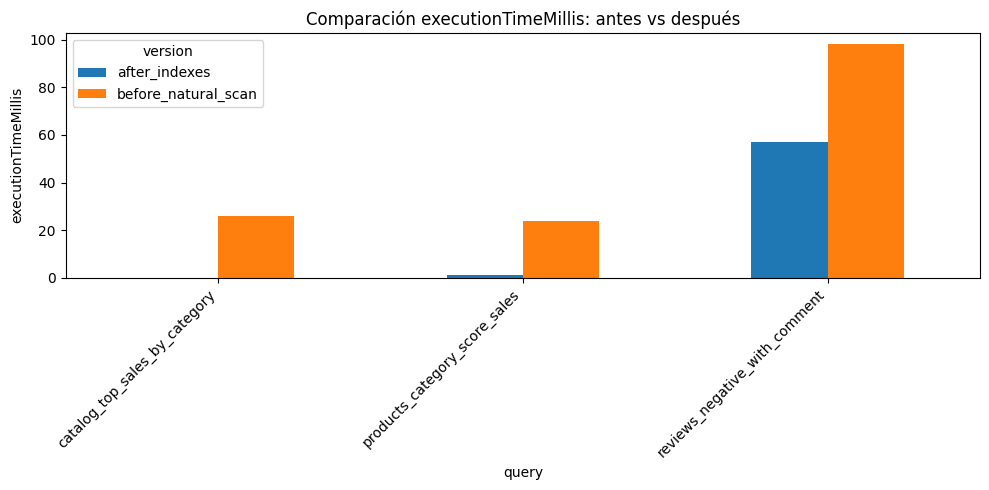

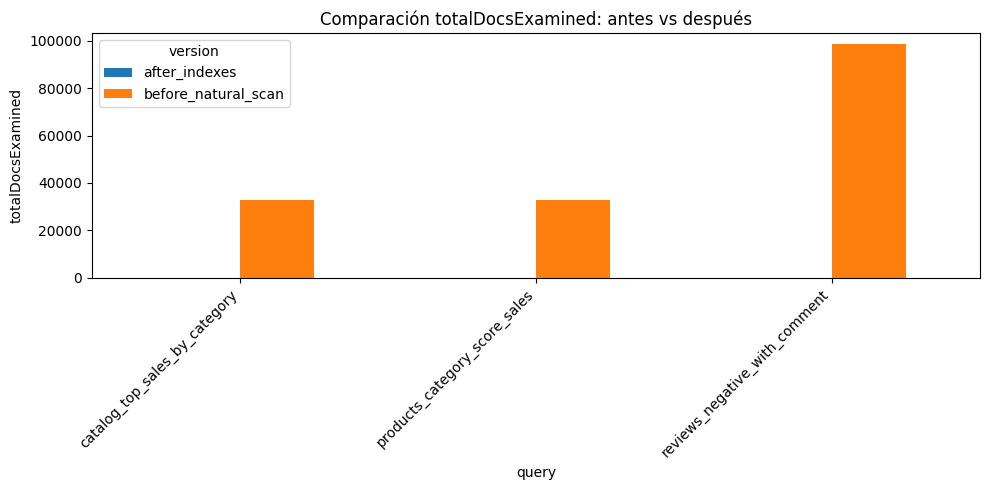

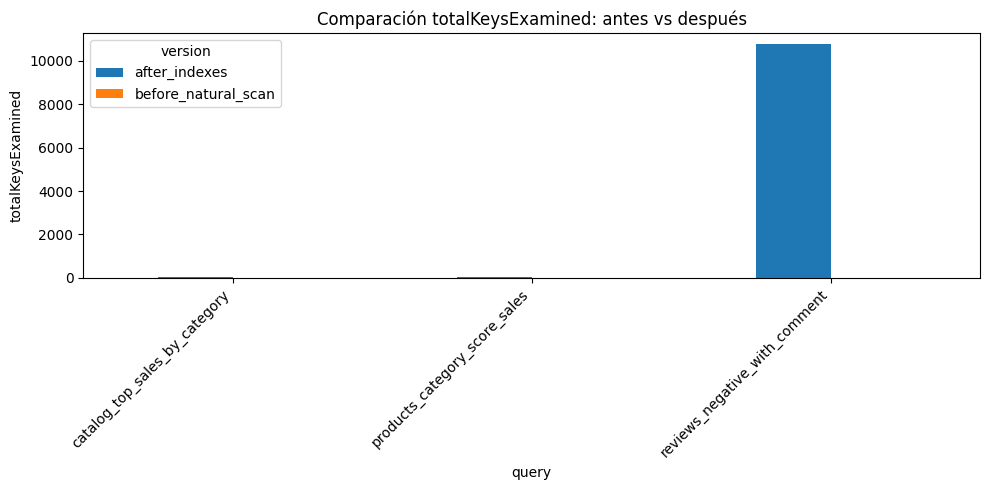

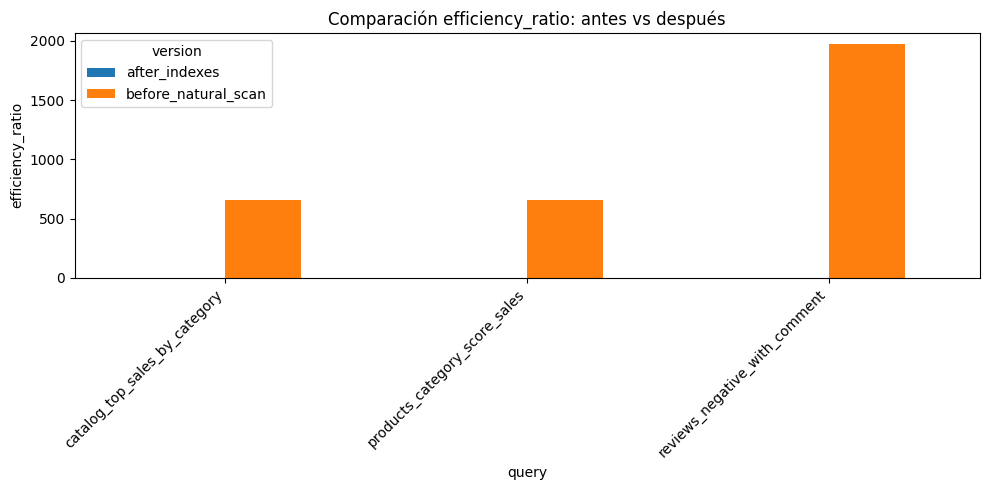

In [18]:
for metric in ['executionTimeMillis', 'totalDocsExamined', 'totalKeysExamined', 'efficiency_ratio']:
    plot_df = performance_df.pivot(index='query', columns='version', values=metric)
    ax = plot_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'Comparación {metric}: antes vs después')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## U5. Aggregation pipelines optimizados

Pipelines con mínimo 5 stages, incluyendo `$match`, transformación, `$sort`, `$group` y `$facet`/`$unwind`/`$bucket`.

In [19]:
pipeline_catalog_by_category = [
    {'$match': {'category.name_en': category_name}},
    {'$addFields': {'weighted_score': {'$add': [
        {'$multiply': ['$metrics.avg_review_score', 0.7]},
        {'$multiply': [{'$ln': {'$add': ['$metrics.total_sales', 1]}}, 0.3]}
    ]}}},
    {'$project': {'_id': 0, 'product_id': 1, 'category': 1, 'metrics': 1, 'weighted_score': 1}},
    {'$sort': {'weighted_score': -1, 'metrics.total_sales': -1}},
    {'$facet': {
        'top_products': [{'$limit': 10}],
        'summary': [{'$group': {
            '_id': '$category.name_en',
            'products': {'$sum': 1},
            'avg_review_score': {'$avg': '$metrics.avg_review_score'},
            'total_sales': {'$sum': '$metrics.total_sales'},
            'total_revenue': {'$sum': '$metrics.total_revenue'}
        }}]
    }}
]

catalog_result = list(db.product_catalog_view.aggregate(pipeline_catalog_by_category, allowDiskUse=True))
display(catalog_result)

[{'top_products': [{'product_id': '11250b0d4b709fee92441c5f34122aed',
    'category': {'name_pt': 'agro_industria_e_comercio',
     'name_en': 'agro_industry_and_commerce'},
    'metrics': {'avg_review_score': 4.71,
     'total_reviews': 21,
     'total_sales': 22,
     'total_revenue': 9111.0},
    'weighted_score': 4.237648264778745},
   {'product_id': 'b5aebb467d9a92162173cbd234e00d99',
    'category': {'name_pt': 'agro_industria_e_comercio',
     'name_en': 'agro_industry_and_commerce'},
    'metrics': {'avg_review_score': 4.75,
     'total_reviews': 8,
     'total_sales': 10,
     'total_revenue': 350.0},
    'weighted_score': 4.044368581839511},
   {'product_id': '980ecbcc15fe174ec1e5757c4d75b1bf',
    'category': {'name_pt': 'agro_industria_e_comercio',
     'name_en': 'agro_industry_and_commerce'},
    'metrics': {'avg_review_score': 4.67,
     'total_reviews': 3,
     'total_sales': 8,
     'total_revenue': 197.5},
    'weighted_score': 3.9281673732008655},
   {'product_id': '

In [20]:
pipeline_reviews_analysis = [
    {'$match': {'score': {'$gte': 1, '$lte': 5}}},
    {'$unwind': {'path': '$product_ids', 'preserveNullAndEmptyArrays': False}},
    {'$group': {
        '_id': {'product_id': '$product_ids', 'score': '$score'},
        'reviews': {'$sum': 1},
        'with_comment': {'$sum': {'$cond': [{'$ifNull': ['$comment.message', False]}, 1, 0]}}
    }},
    {'$project': {
        '_id': 0,
        'product_id': '$_id.product_id',
        'score': '$_id.score',
        'reviews': 1,
        'with_comment': 1,
        'comment_rate': {'$cond': [{'$gt': ['$reviews', 0]}, {'$divide': ['$with_comment', '$reviews']}, 0]}
    }},
    {'$sort': {'reviews': -1, 'score': 1}},
    {'$limit': 20}
]

reviews_analysis = list(db.reviews.aggregate(pipeline_reviews_analysis, allowDiskUse=True))
display(pd.DataFrame(reviews_analysis))

,reviews,with_comment,product_id,score,comment_rate
0,229,67,aca2eb7d00ea1a7b8ebd4e68314663af,5,0.292576
1,227,95,99a4788cb24856965c36a24e339b6058,5,0.418502
2,212,94,422879e10f46682990de24d770e7f83d,5,0.443396
3,197,70,d1c427060a0f73f6b889a5c7c61f2ac4,5,0.355330
4,194,86,389d119b48cf3043d311335e499d9c6b,5,0.443299
5,187,59,53b36df67ebb7c41585e8d54d6772e08,5,0.315508
6,178,70,154e7e31ebfa092203795c972e5804a6,5,0.393258
7,171,78,368c6c730842d78016ad823897a372db,5,0.456140
8,165,68,53759a2ecddad2bb87a079a1f1519f73,5,0.412121
9,155,63,3dd2a17168ec895c781a9191c1e95ad7,5,0.406452


In [21]:
pipeline_top_products = [
    {'$match': {'metrics.total_sales': {'$gt': 0}, 'metrics.avg_review_score': {'$gt': 0}}},
    {'$addFields': {'quality_score': {'$multiply': ['$metrics.avg_review_score', {'$ln': {'$add': ['$metrics.total_sales', 1]}}]}}},
    {'$project': {'_id': 0, 'product_id': 1, 'category.name_en': 1, 'metrics': 1, 'quality_score': 1}},
    {'$sort': {'quality_score': -1}},
    {'$facet': {
        'top_20': [{'$limit': 20}],
        'sales_buckets': [{'$bucket': {
            'groupBy': '$metrics.total_sales',
            'boundaries': [0, 1, 5, 10, 25, 50, 100, 500, 10000],
            'default': 'other',
            'output': {'products': {'$sum': 1}, 'avg_review_score': {'$avg': '$metrics.avg_review_score'}}
        }}]
    }}
]

top_products_result = list(db.product_catalog_view.aggregate(pipeline_top_products, allowDiskUse=True))
display(top_products_result)

[{'top_20': [{'product_id': 'aca2eb7d00ea1a7b8ebd4e68314663af',
    'category': {'name_en': 'furniture_decor'},
    'metrics': {'avg_review_score': 4.1,
     'total_reviews': 429,
     'total_sales': 527,
     'total_revenue': 37608.9},
    'quality_score': 25.703294763195668},
   {'product_id': '422879e10f46682990de24d770e7f83d',
    'category': {'name_en': 'garden_tools'},
    'metrics': {'avg_review_score': 4.13,
     'total_reviews': 351,
     'total_sales': 484,
     'total_revenue': 26577.22},
    'quality_score': 25.540534919571805},
   {'product_id': '389d119b48cf3043d311335e499d9c6b',
    'category': {'name_en': 'garden_tools'},
    'metrics': {'avg_review_score': 4.18,
     'total_reviews': 310,
     'total_sales': 392,
     'total_revenue': 21440.59},
    'quality_score': 24.97052417761351},
   {'product_id': 'd1c427060a0f73f6b889a5c7c61f2ac4',
    'category': {'name_en': 'computers_accessories'},
    'metrics': {'avg_review_score': 4.23,
     'total_reviews': 320,
     'tot

In [39]:
def explain_aggregation(collection_name, pipeline):
    return db.command('aggregate', collection_name, pipeline=pipeline, explain=True, allowDiskUse=True)

explain_catalog = explain_aggregation('product_catalog_view', pipeline_catalog_by_category)
explain_reviews = explain_aggregation('reviews', pipeline_reviews_analysis)
explain_top = explain_aggregation('product_catalog_view', pipeline_top_products)
print('Explain generado para los 3 pipelines.')
print('Claves explain_catalog:', list(explain_catalog.keys()))

Explain generado para los 3 pipelines.
Claves explain_catalog: ['explainVersion', 'stages', 'queryShapeHash', 'serverInfo', 'serverParameters', 'command', 'ok', '$clusterTime', 'operationTime']


## U5. Diseño teórico de sharding

Atlas M0 no permite sharding real. Se documenta y simula.

Shard key recomendada:

```javascript
{ "category.name_en": 1, "_id": "hashed" }
```

Comparacion:
- `{ _id: "hashed" }`: distribucion uniforme, pero consultas por categoria scatter-gather.
- `{ category.name_en: 1 }`: consultas por categoria eficientes, pero riesgo de hotspots.
- `{ "category.name_en": 1, "_id": "hashed" }`: balance entre eficiencia y distribucion.


,category,products,share,hhi_component
0,bed_bath_table,3029,0.091924,0.008450
1,sports_leisure,2867,0.087008,0.007570
2,furniture_decor,2657,0.080635,0.006502
3,health_beauty,2444,0.074171,0.005501
4,housewares,2335,0.070863,0.005022
5,auto,1900,0.057661,0.003325
6,computers_accessories,1639,0.049741,0.002474
7,toys,1411,0.042821,0.001834
8,watches_gifts,1329,0.040333,0.001627
9,telephony,1134,0.034415,0.001184


HHI concentración por categoría: 0.0495

 shard_id_hashed


,documents
shard_id_hashed,
0,8314
1,8366
2,8195
3,8076



 shard_category_only


,documents
shard_category_only,
0,8245
1,16136
2,3407
3,5163



 shard_compound


,documents
shard_compound,
0,8305
1,8261
2,8245
3,8140


,strategy,min_docs,max_docs,std_docs,imbalance_ratio_max_min
0,shard_id_hashed,8076,8366,129.43,1.04
1,shard_category_only,3407,16136,5632.43,4.74
2,shard_compound,8140,8305,69.93,1.02


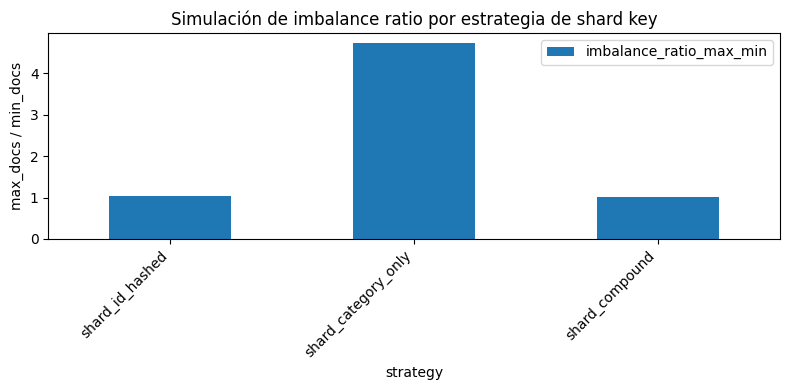

In [41]:
category_distribution = product_enriched['product_category_name_english'].fillna('unknown').value_counts().reset_index()
category_distribution.columns = ['category', 'products']
category_distribution['share'] = category_distribution['products'] / category_distribution['products'].sum()
category_distribution['hhi_component'] = category_distribution['share'] ** 2
hhi = category_distribution['hhi_component'].sum()
display(category_distribution.head(10))
print('HHI concentración por categoría:', round(hhi, 4))

import hashlib

def stable_hash_to_shard(value, n_shards=4):
    h = int(hashlib.md5(str(value).encode('utf-8')).hexdigest(), 16)
    return h % n_shards

n_shards = 4
sim_df = product_enriched[['product_id', 'product_category_name_english']].copy()
sim_df['category'] = sim_df['product_category_name_english'].fillna('unknown')
sim_df['shard_id_hashed'] = sim_df['product_id'].apply(lambda x: stable_hash_to_shard(x, n_shards))
sim_df['shard_category_only'] = sim_df['category'].apply(lambda x: stable_hash_to_shard(x, n_shards))
sim_df['shard_compound'] = sim_df.apply(lambda r: stable_hash_to_shard(str(r['category']) + '-' + str(r['product_id']), n_shards), axis=1)

simulation_rows = []
for col in ['shard_id_hashed', 'shard_category_only', 'shard_compound']:
    counts_sim = sim_df[col].value_counts().sort_index()
    simulation_rows.append({
        'strategy': col,
        'min_docs': int(counts_sim.min()),
        'max_docs': int(counts_sim.max()),
        'std_docs': round(float(counts_sim.std()), 2),
        'imbalance_ratio_max_min': round(float(counts_sim.max() / counts_sim.min()), 2)
    })
    print('\n', col)
    display(counts_sim.to_frame('documents'))

simulation_df = pd.DataFrame(simulation_rows)
display(simulation_df)
simulation_df.plot(x='strategy', y='imbalance_ratio_max_min', kind='bar', figsize=(8,4))
plt.title('Simulación de imbalance ratio por estrategia de shard key')
plt.ylabel('max_docs / min_docs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## U5. Replica set, Read Preference y Write Concern

- Replica set teórico: 3 nodos, 1 Primary y 2 Secondary.
- Operaciones críticas: `readPreference=primary`, `writeConcern={w: "majority", j: true}`.
- Catálogo y analítica: `readPreference=secondaryPreferred`, `writeConcern={w: 1}`.
- Mitigación de consistencia eventual: primary en operaciones críticas, causal consistency sessions y readConcern majority.

In [42]:
from pymongo import ReadPreference, WriteConcern
from pymongo.read_concern import ReadConcern

critical_collection = db.get_collection(
    'orders_theoretical',
    read_preference=ReadPreference.PRIMARY,
    write_concern=WriteConcern(w='majority', j=True),
    read_concern=ReadConcern('majority')
)
analytics_collection = db.get_collection(
    'product_catalog_view',
    read_preference=ReadPreference.SECONDARY_PREFERRED,
    write_concern=WriteConcern(w=1)
)
print('Configuraciones teóricas de Read/Write Concern listas.')

Configuraciones teóricas de Read/Write Concern listas.


## U5. Exportables para GitHub

Genera archivos en `/content/ecommify_mongodb_github/mongodb`.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
OUTPUT_DIR = Path('/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb')
for folder in ['schemas', 'indexes', 'queries', 'pipelines', 'docs']:
    (OUTPUT_DIR / folder).mkdir(parents=True, exist_ok=True)

schemas_js = '/* Ecommify MongoDB JSON Schemas */\n\nconst validators = ' + json.dumps(validators, default=str, indent=2, ensure_ascii=False) + ';\n'
(OUTPUT_DIR / 'schemas' / 'ecommify_mongodb_schemas.js').write_text(schemas_js, encoding='utf-8')

indexes_js = '// Ecommify MongoDB Indexes\n\n'
for cname in collection_names:
    indexes_js += f'// Indexes for {cname}\n'
    for idx in db[cname].list_indexes():
        indexes_js += f'// {idx}\n'
    indexes_js += '\n'
(OUTPUT_DIR / 'indexes' / 'ecommify_indexes.js').write_text(indexes_js, encoding='utf-8')

queries_js = (
    '// Ecommify Optimized Queries\n\n'
    f'db.products.find({{ "category.name_en": "{category_name}", status: "active" }}).sort({{ "analytics.avg_review_score": -1, "analytics.total_sales": -1 }}).limit(20);\n\n'
    'db.reviews.find({ score: { $lte: 2 }, "comment.message": { $exists: true } }).sort({ created_at: -1 }).limit(20);\n\n'
    f'db.product_catalog_view.find({{ "category.name_en": "{category_name}" }}).sort({{ "metrics.total_sales": -1 }}).limit(20);\n'
)
(OUTPUT_DIR / 'queries' / 'optimized_queries.js').write_text(queries_js, encoding='utf-8')

pipelines_js = '/* Ecommify Aggregation Pipelines */\n\n'
pipelines_js += 'const pipeline_catalog_by_category = ' + json.dumps(pipeline_catalog_by_category, default=str, indent=2, ensure_ascii=False) + ';\n\n'
pipelines_js += 'const pipeline_reviews_analysis = ' + json.dumps(pipeline_reviews_analysis, default=str, indent=2, ensure_ascii=False) + ';\n\n'
pipelines_js += 'const pipeline_top_products = ' + json.dumps(pipeline_top_products, default=str, indent=2, ensure_ascii=False) + ';\n'
(OUTPUT_DIR / 'pipelines' / 'aggregation_pipelines.js').write_text(pipelines_js, encoding='utf-8')

sharding_md = (
    '# Ecommify Sharding Strategy\n\n'
    'Atlas M0 no permite sharding real. Se documenta y simula.\n\n'
    '## Shard key propuesta\n\n'
    '```javascript\n{ "category.name_en": 1, "_id": "hashed" }\n```\n\n'
    f'HHI calculado por categoría: {round(hhi, 4)}.\n'
)
(OUTPUT_DIR / 'docs' / 'sharding_strategy.md').write_text(sharding_md, encoding='utf-8')
performance_md = '# Ecommify MongoDB Performance Results\n\n' + performance_df.to_markdown(index=False)
(OUTPUT_DIR / 'docs' / 'performance_results.md').write_text(performance_md, encoding='utf-8')

print('Archivos exportados en:', OUTPUT_DIR)
for p in OUTPUT_DIR.rglob('*'):
    if p.is_file():
        print(p)

Archivos exportados en: /content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/schemas/ecommify_mongodb_schemas.js
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/indexes/ecommify_indexes.js
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/queries/optimized_queries.js
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/pipelines/aggregation_pipelines.js
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/docs/sharding_strategy.md
/content/drive/MyDrive/Ecommify/ecommify_mongodb_github/mongodb/docs/performance_results.md


In [30]:
# M4: 100% de product_id presentes en order_items deben existir en MongoDB products.
product_ids_order_items = set(order_items['product_id'].dropna().astype(str))
product_ids_mongo = set(doc['product_id'] for doc in db.products.find({}, {'product_id': 1, '_id': 0}))
missing_in_mongo = product_ids_order_items - product_ids_mongo
coverage = round((1 - len(missing_in_mongo) / len(product_ids_order_items)) * 100, 4) if product_ids_order_items else 100

print('Product IDs en order_items:', len(product_ids_order_items))
print('Product IDs en MongoDB products:', len(product_ids_mongo))
print('Faltantes en MongoDB:', len(missing_in_mongo))
print('M4 cobertura product_id (%):', coverage)
assert coverage == 100, 'M4 no se cumple: hay product_id faltantes en MongoDB products.'
print('M4 cumplida: 100% de product_id de order_items existe en products.')

Product IDs en order_items: 32951
Product IDs en MongoDB products: 32951
Faltantes en MongoDB: 0
M4 cobertura product_id (%): 100.0
M4 cumplida: 100% de product_id de order_items existe en products.


## 17. Consultas MongoDB de ejemplo

In [31]:
# 1. Buscar productos por categoría.
category_example = db.products.find_one({'category.name_en': {'$exists': True}}, {'category.name_en': 1})
category_name = category_example['category']['name_en'] if category_example else 'bed_bath_table'

list(db.products.find(
    {'category.name_en': category_name},
    {'_id': 0, 'product_id': 1, 'category': 1, 'analytics': 1}
).limit(5))

[{'product_id': '07f01b6fcacc1b187a71e5074199db2d',
  'category': {'name_pt': 'agro_industria_e_comercio',
   'name_en': 'agro_industry_and_commerce'},
  'analytics': {'avg_review_score': 5.0,
   'total_reviews': 1,
   'total_sales': 1}},
 {'product_id': '613d093272cb8f74f25a01e430155a6a',
  'category': {'name_pt': 'agro_industria_e_comercio',
   'name_en': 'agro_industry_and_commerce'},
  'analytics': {'avg_review_score': 5.0,
   'total_reviews': 1,
   'total_sales': 1}},
 {'product_id': '980ecbcc15fe174ec1e5757c4d75b1bf',
  'category': {'name_pt': 'agro_industria_e_comercio',
   'name_en': 'agro_industry_and_commerce'},
  'analytics': {'avg_review_score': 4.67,
   'total_reviews': 3,
   'total_sales': 8}},
 {'product_id': 'ba1d7e7ee1f055d252a2faa8ea3cea9b',
  'category': {'name_pt': 'agro_industria_e_comercio',
   'name_en': 'agro_industry_and_commerce'},
  'analytics': {'avg_review_score': 5.0,
   'total_reviews': 1,
   'total_sales': 1}},
 {'product_id': '137ace556a03792cdc43f91ec6

In [32]:
# 2. Filtrar productos con score promedio mayor a 4.
list(db.products.find(
    {'analytics.avg_review_score': {'$gte': 4}},
    {'_id': 0, 'product_id': 1, 'category.name_en': 1, 'analytics.avg_review_score': 1, 'analytics.total_sales': 1}
).sort('analytics.avg_review_score', DESCENDING).limit(10))

[{'product_id': '1e9e8ef04dbcff4541ed26657ea517e5',
  'category': {'name_en': 'perfumery'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 1}},
 {'product_id': '3aa071139cb16b67ca9e5dea641aaa2f',
  'category': {'name_en': 'art'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 1}},
 {'product_id': '96bd76ec8810374ed1b65e291975717f',
  'category': {'name_en': 'sports_leisure'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 1}},
 {'product_id': '9dc1a7de274444849c219cff195d0b71',
  'category': {'name_en': 'housewares'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 1}},
 {'product_id': '41d3672d4792049fa1779bb35283ed13',
  'category': {'name_en': 'musical_instruments'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 1}},
 {'product_id': '14aa47b7fe5c25522b47b4b29c98dcb9',
  'category': {'name_en': 'bed_bath_table'},
  'analytics': {'avg_review_score': 5.0, 'total_sales': 4}},
 {'product_id': 'cf55509ea8edaaac1d28fdb16e48fc22',
  'category': {

In [33]:
# 3. Buscar reseñas negativas con comentario.
list(db.reviews.find(
    {'score': {'$lte': 2}, 'comment.message': {'$exists': True}},
    {'_id': 0, 'review_id': 1, 'order_id': 1, 'score': 1, 'comment': 1}
).limit(5))

[{'review_id': '69ac6a27fde9855ebeaaecac0f78058b',
  'order_id': '809a282bbd5dbcabb6f2f724fca862ec',
  'score': 1,
  'comment': {'message': 'MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NENHUMA SATISTAÇÃO'}},
 {'review_id': '6916ca4502d6d3bfd39818759d55d536',
  'order_id': 'bfbd0f9bdef84302105ad712db648a6c',
  'score': 1,
  'comment': {'message': 'nao recebi o produto e nem resposta da empresa'}},
 {'review_id': '49f695dffa457eaba90d388a5c37e942',
  'order_id': 'e5215415bb6f76fe3b7cb68103a0d1c0',
  'score': 1,
  'comment': {'message': 'PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA'}},
 {'review_id': '3ec60dec755e23c788b026be90faa337',
  'order_id': 'fb5114c39f632a52598cf770c6076620',
  'score': 1,
  'comment': {'message': 'Comprei uma capa para um tablet e a que foi entregue não foi a que escolhi no site da lannister.\r\nNão emitiram a nota fiscal do produto.\r\nNunca mais compro nada desses parceiros da lannister.'}},
 {'review_id': 'b28309e8253951a954123e039d3242f7',
  'order_id': 

In [43]:
# 4. Búsqueda de texto en comentarios.
list(db.reviews.find(
    {'$text': {'$search': 'produto'}},
    {'score_text': {'$meta': 'textScore'}, '_id': 0, 'review_id': 1, 'score': 1, 'comment.message': 1}
).sort([('score_text', {'$meta': 'textScore'})]).limit(5))

[{'review_id': 'f48fbc503f41cb74c42e280fc548d1a7',
  'score': 4,
  'comment': {'message': 'Recebi o produto dentro do prazo estabelecido pela empresa. O produto é top! Recomendo o produto e a loja.'},
  'score_text': 1.7794117647058825},
 {'review_id': '7b192fe96fcea11bb4146e7b13ea8de9',
  'score': 5,
  'comment': {'message': 'excelente produto, recomendo.'},
  'score_text': 1.7666666666666666},
 {'review_id': '0b7f1d51251cdd73346eed0296022fee',
  'score': 1,
  'comment': {'message': 'Demorou para chegar e não veio o produto que comprei. Produto mau embalado, Produto errado e NF dentro do produto em nome de outra pessoa. Péssimo! Quero meu dinheiro de volta!'},
  'score_text': 1.7291666666666665},
 {'review_id': '9d24cc0f680e853ebf91de8d1ae80c4a',
  'score': 3,
  'comment': {'message': 'Paguei o frete, porém, não vêm em casa o produto, outra coisa a foto do produto foi uma, o que foi entregue foi outro produto. Que por sua vez não veio pronto pra ser usado, tive que cortar pra usar.'},

In [35]:
# 5. Vista de catálogo ordenada por ventas.
list(db.product_catalog_view.find(
    {},
    {'_id': 0, 'product_id': 1, 'category.name_en': 1, 'metrics': 1, 'top_sellers': 1}
).sort('metrics.total_sales', DESCENDING).limit(10))

[{'product_id': 'aca2eb7d00ea1a7b8ebd4e68314663af',
  'category': {'name_en': 'furniture_decor'},
  'metrics': {'avg_review_score': 4.1,
   'total_reviews': 429,
   'total_sales': 527,
   'total_revenue': 37608.9},
  'top_sellers': [{'seller_id': '955fee9216a65b617aa5c0531780ce60',
    'sales': 527,
    'revenue': 37608.9}]},
 {'product_id': '99a4788cb24856965c36a24e339b6058',
  'category': {'name_en': 'bed_bath_table'},
  'metrics': {'avg_review_score': 3.9,
   'total_reviews': 460,
   'total_sales': 488,
   'total_revenue': 43025.56},
  'top_sellers': [{'seller_id': '4a3ca9315b744ce9f8e9374361493884',
    'sales': 482,
    'revenue': 42518.4},
   {'seller_id': '53d00c40e32aeb924a84ce72b1af869d',
    'sales': 6,
    'revenue': 507.16}]},
 {'product_id': '422879e10f46682990de24d770e7f83d',
  'category': {'name_en': 'garden_tools'},
  'metrics': {'avg_review_score': 4.13,
   'total_reviews': 351,
   'total_sales': 484,
   'total_revenue': 26577.22},
  'top_sellers': [{'seller_id': '1f50

In [36]:
# 6. Recomendaciones de un cliente.
example_customer = recommendation_docs[0]['customer_id']
db.recommendations.find_one({'customer_id': example_customer}, {'_id': 0})

{'customer_id': 'c7432c6d237ffd6aa36a007b4237ec38',
 'generated_at': datetime.datetime(2026, 6, 15, 16, 6, 49, 66000),
 'recommendations': [{'product_id': 'aca2eb7d00ea1a7b8ebd4e68314663af',
   'score': 0.95,
   'reason': 'Producto popular con buen desempeño histórico',
   'category': 'furniture_decor'},
  {'product_id': '99a4788cb24856965c36a24e339b6058',
   'score': 0.92,
   'reason': 'Producto popular con buen desempeño histórico',
   'category': 'bed_bath_table'},
  {'product_id': '422879e10f46682990de24d770e7f83d',
   'score': 0.89,
   'reason': 'Producto popular con buen desempeño histórico',
   'category': 'garden_tools'},
  {'product_id': '389d119b48cf3043d311335e499d9c6b',
   'score': 0.86,
   'reason': 'Producto popular con buen desempeño histórico',
   'category': 'garden_tools'},
  {'product_id': '368c6c730842d78016ad823897a372db',
   'score': 0.83,
   'reason': 'Producto popular con buen desempeño histórico',
   'category': 'garden_tools'}]}

In [37]:
# 7. Eventos de user_behavior asociados a un producto.
example_product = behavior_docs[0]['events'][0].get('product_id')
if example_product:
    result = list(db.user_behavior.find(
        {'events.product_id': example_product},
        {'_id': 0, 'customer_id': 1, 'session_id': 1, 'events': 1}
    ).limit(5))
else:
    result = []
result

[{'customer_id': 'c7432c6d237ffd6aa36a007b4237ec38',
  'session_id': 'session_000001',
  'events': [{'type': 'view_product',
    'timestamp': datetime.datetime(2026, 6, 15, 6, 43, 49, 66000),
    'product_id': 'deaa363c2aa7c56c84e888bb74cc7176',
    'category': 'bed_bath_table'},
   {'type': 'add_to_cart',
    'timestamp': datetime.datetime(2026, 6, 15, 6, 45, 49, 66000),
    'product_id': 'cf8c588a4b9b7599aa4807e78bbc65a9',
    'category': 'computers_accessories'}]}]